# Pronunciation Scoring Pipeline — Architecture Overview

This notebook visualizes the **process and architecture of each stage** of the pipeline:

| Stage | Package | What it does |
|---|---|---|
| **Stage 1** | `stage1_ctc/` | Fine-tunes HuBERT-Large with **CTC** on SpeechOcean762 transcripts (text-prediction pretext task) |
| **Stage 2** | `stage2_scoring/` | Trains **HubertMultiTask** (audio + reference-text fusion) to predict utterance-level pronunciation scores |

The diagrams are drawn with matplotlib; the introspection cells at the end load the real
model and verify the tensor shapes / parameter freeze map against the diagrams.

> Run from the repo root or from `notebooks/` — the setup cell handles both.

In [1]:
%matplotlib inline
import os, sys, json

# Make repo-root imports work whether launched from the root or from notebooks/
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# One color per role, used consistently across all diagrams
PALETTE = {
    "data":   dict(fc="#fff8e1", ec="#f9ab00"),   # datasets / raw inputs
    "audio":  dict(fc="#e8f0fe", ec="#1a73e8"),   # audio stream
    "text":   dict(fc="#e6f4ea", ec="#188038"),   # text stream
    "fusion": dict(fc="#f3e8fd", ec="#8430ce"),   # fusion / refinement
    "head":   dict(fc="#fce8e6", ec="#d93025"),   # output heads / losses
    "frozen": dict(fc="#f1f3f4", ec="#5f6368"),   # frozen components
}

def box(ax, cx, cy, w, h, label, kind="audio", fs=9, ls="-"):
    c = PALETTE[kind]
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=c["fc"], ec=c["ec"], lw=1.5, linestyle=ls))
    ax.text(cx, cy, label, ha="center", va="center", fontsize=fs)

def arrow(ax, p0, p1, label="", color="#444", ls="-", fs=8, dx=0.12, dy=0.0):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=13,
                                 color=color, lw=1.4, linestyle=ls,
                                 shrinkA=2, shrinkB=2))
    if label:
        ax.text((p0[0]+p1[0])/2 + dx, (p0[1]+p1[1])/2 + dy, label,
                fontsize=fs, color=color, ha="left", va="center")

def vflow(ax, cx, top, items, w=4.0, gap=0.5, fs=9):
    """Vertical chain of boxes: items = [(label, kind, height), ...].
    Returns [(cx, y_top, y_bottom), ...] so callers can attach extra arrows."""
    pos, y = [], top
    for label, kind, h in items:
        box(ax, cx, y - h/2, w, h, label, kind, fs)
        pos.append((cx, y, y - h))
        y -= h + gap
    for (c0, _, b0), (c1, t1, _) in zip(pos, pos[1:]):
        arrow(ax, (c0, b0), (c1, t1))
    return pos

def canvas(w, h, title, xmax=10, ymax=10):
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax); ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")
    return fig, ax

print("Repo root:", ROOT)

Repo root: /workspace/pronunciation-scoring


## End-to-end pipeline

How the two stages connect: Stage 1 produces a CTC fine-tuned encoder; Stage 2 can start
from it (`--backbone stage1`) or from the stock pretrained checkpoint (`--backbone hubert-large`).

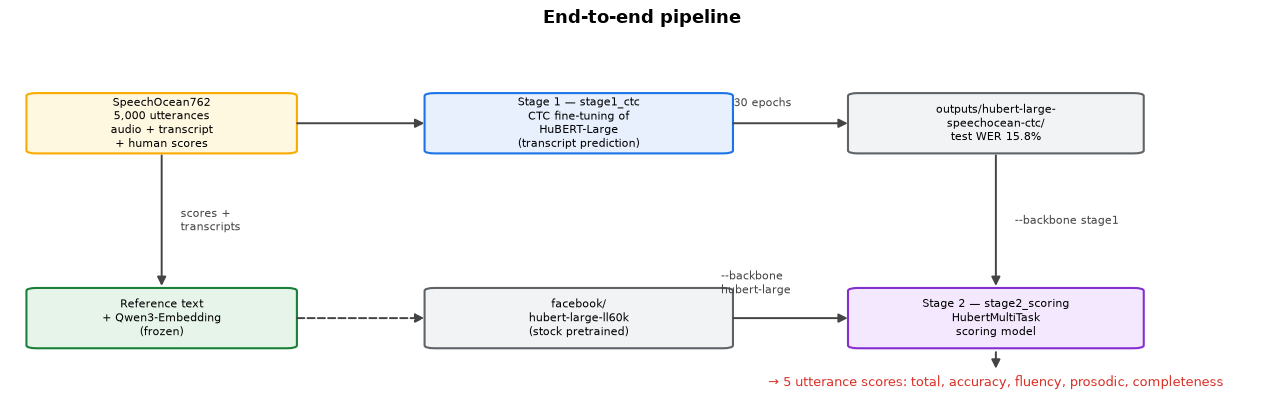

In [2]:
fig, ax = canvas(13, 4.2, "End-to-end pipeline")

box(ax, 1.2, 7.5, 2.1, 1.6, "SpeechOcean762\n5,000 utterances\naudio + transcript\n+ human scores", "data", 8)
box(ax, 4.5, 7.5, 2.4, 1.6, "Stage 1 — stage1_ctc\nCTC fine-tuning of\nHuBERT-Large\n(transcript prediction)", "audio", 8)
box(ax, 7.8, 7.5, 2.3, 1.6, "outputs/hubert-large-\nspeechocean-ctc/\ntest WER 15.8%", "frozen", 8)
box(ax, 4.5, 2.2, 2.4, 1.6, "facebook/\nhubert-large-ll60k\n(stock pretrained)", "frozen", 8)
box(ax, 1.2, 2.2, 2.1, 1.6, "Reference text\n+ Qwen3-Embedding\n(frozen)", "text", 8)
box(ax, 7.8, 2.2, 2.3, 1.6, "Stage 2 — stage2_scoring\nHubertMultiTask\nscoring model", "fusion", 8)

arrow(ax, (2.25, 7.5), (3.3, 7.5))
arrow(ax, (5.7, 7.5), (6.65, 7.5), "30 epochs", dx=-0.45, dy=0.55)
arrow(ax, (7.8, 6.7), (7.8, 3.0), "--backbone stage1", dx=0.15)
arrow(ax, (5.7, 2.2), (6.65, 2.2), "--backbone\nhubert-large", dx=-0.55, dy=0.95)
arrow(ax, (2.25, 2.2), (3.3, 2.2), "", ls="--")
arrow(ax, (1.2, 6.7), (1.2, 3.0), "scores +\ntranscripts", dx=0.15)

ax.text(7.8, 0.35, "→ 5 utterance scores: total, accuracy, fluency, prosodic, completeness",
        fontsize=9, ha="center", color="#d93025")
arrow(ax, (7.8, 1.35), (7.8, 0.75))
plt.tight_layout(); plt.show()

## Stage 1 — CTC fine-tuning (`stage1_ctc/`)

The audio and transcript columns of the dataset are prepared separately, joined by the
`Wav2Vec2Processor`, and used to fine-tune `HubertForCTC`. Only the transformer layers
train — the CNN feature extractor stays frozen.

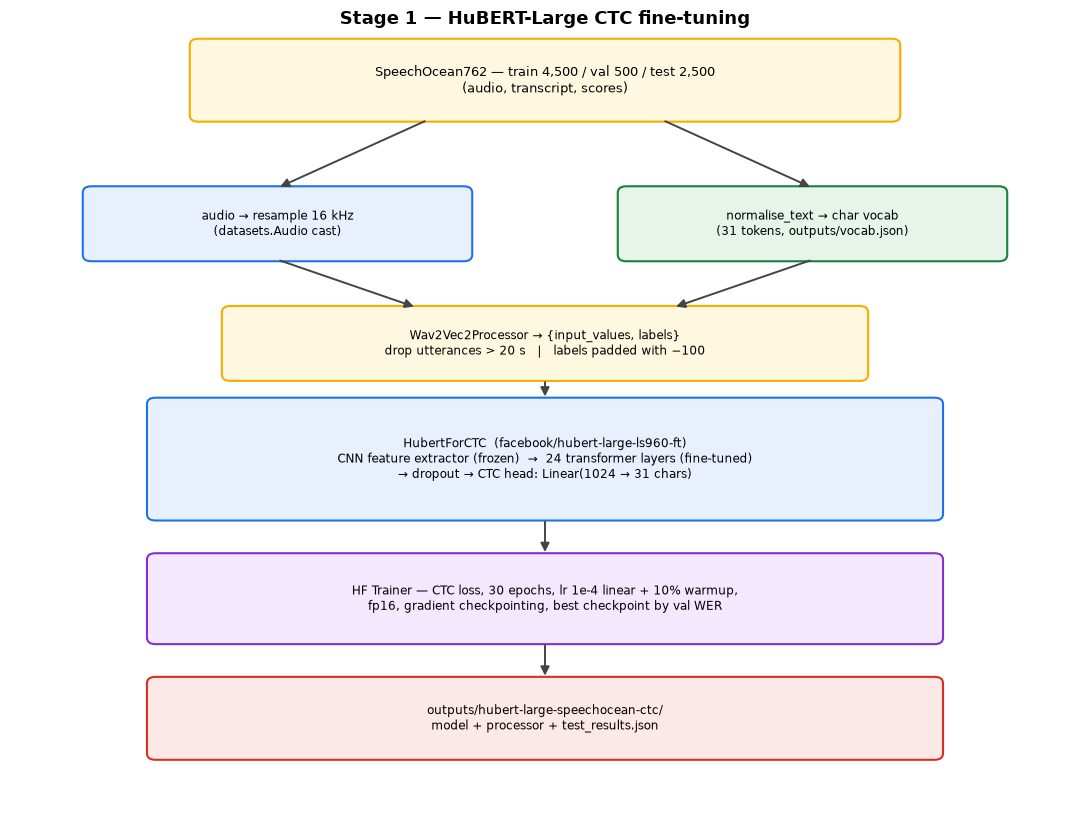

In [3]:
fig, ax = canvas(11, 8.5, "Stage 1 — HuBERT-Large CTC fine-tuning")

box(ax, 5.0, 9.4, 6.6, 1.0, "SpeechOcean762 — train 4,500 / val 500 / test 2,500\n(audio, transcript, scores)", "data", 9)

# split: audio left, text right
box(ax, 2.5, 7.6, 3.6, 0.9, "audio → resample 16 kHz\n(datasets.Audio cast)", "audio", 8.5)
box(ax, 7.5, 7.6, 3.6, 0.9, "normalise_text → char vocab\n(31 tokens, outputs/vocab.json)", "text", 8.5)
arrow(ax, (3.9, 8.9), (2.5, 8.05))
arrow(ax, (6.1, 8.9), (7.5, 8.05))

box(ax, 5.0, 6.1, 6.0, 0.9, "Wav2Vec2Processor → {input_values, labels}\ndrop utterances > 20 s   |   labels padded with −100", "data", 8.5)
arrow(ax, (2.5, 7.15), (3.8, 6.55))
arrow(ax, (7.5, 7.15), (6.2, 6.55))

vflow(ax, 5.0, 5.4, [
    ("HubertForCTC  (facebook/hubert-large-ls960-ft)\n"
     "CNN feature extractor (frozen)  →  24 transformer layers (fine-tuned)\n"
     "→ dropout → CTC head: Linear(1024 → 31 chars)", "audio", 1.5),
    ("HF Trainer — CTC loss, 30 epochs, lr 1e-4 linear + 10% warmup,\n"
     "fp16, gradient checkpointing, best checkpoint by val WER", "fusion", 1.1),
    ("outputs/hubert-large-speechocean-ctc/\nmodel + processor + test_results.json", "head", 1.0),
], w=7.4, gap=0.45, fs=8.5)
arrow(ax, (5.0, 5.65), (5.0, 5.4))
plt.tight_layout(); plt.show()

### Stage 1 configuration and result (live from `stage1_ctc/config.py`)

In [4]:
import pandas as pd
from stage1_ctc import config as s1

print(f"model    : {s1.MODEL_NAME}")
print(f"dataset  : {s1.DATASET_NAME}")
print(f"output   : {s1.OUTPUT_DIR}")
print(f"vocab    : {s1.VOCAB_PATH}")
print(f"max dur  : {s1.MAX_DURATION_SEC} s")

keys = ["num_train_epochs", "per_device_train_batch_size", "gradient_accumulation_steps",
        "learning_rate", "warmup_ratio", "lr_scheduler_type", "weight_decay",
        "fp16", "gradient_checkpointing", "metric_for_best_model"]
display(pd.DataFrame([(k, s1.TRAINING_ARGS[k]) for k in keys],
                     columns=["hyperparameter", "value"]))

res_path = os.path.join(s1.OUTPUT_DIR, "test_results.json")
if os.path.exists(res_path):
    res = json.load(open(res_path))
    print(f"\nTrained result — test WER: {res['eval_wer']:.4f}  (loss {res['eval_loss']:.4f}, {res['epoch']:.0f} epochs)")
else:
    print("\n(no test_results.json yet — stage 1 not trained on this machine)")

model    : facebook/hubert-large-ls960-ft
dataset  : mispeech/speechocean762
output   : ./outputs/hubert-large-speechocean-ctc
vocab    : ./outputs/vocab.json
max dur  : 20.0 s


,hyperparameter,value
0,num_train_epochs,30
1,per_device_train_batch_size,16
2,gradient_accumulation_steps,4
3,learning_rate,0.0001
4,warmup_ratio,0.1
5,lr_scheduler_type,linear
6,weight_decay,0.01
7,fp16,True
8,gradient_checkpointing,True
9,metric_for_best_model,wer



Trained result — test WER: 0.1581  (loss 0.4502, 30 epochs)


## Stage 2 — HubertMultiTask scoring model (`stage2_scoring/`)

Two streams fused by cross-attention:

- **Audio path** (blue): HuBERT-Large → learnable layer-weighted sum → projection → pre-fusion self-attention.
- **Text path** (green): frozen Qwen3-Embedding of the reference transcript → mean pool → projection. At inference, phone-level pooled audio embeddings from the CTC aligner can be appended (dashed).
- **Fusion & heads** (purple/red): audio queries attend to the text embedding, a Transformer refines the result, and mean pooling feeds the scoring + auxiliary prosody heads.

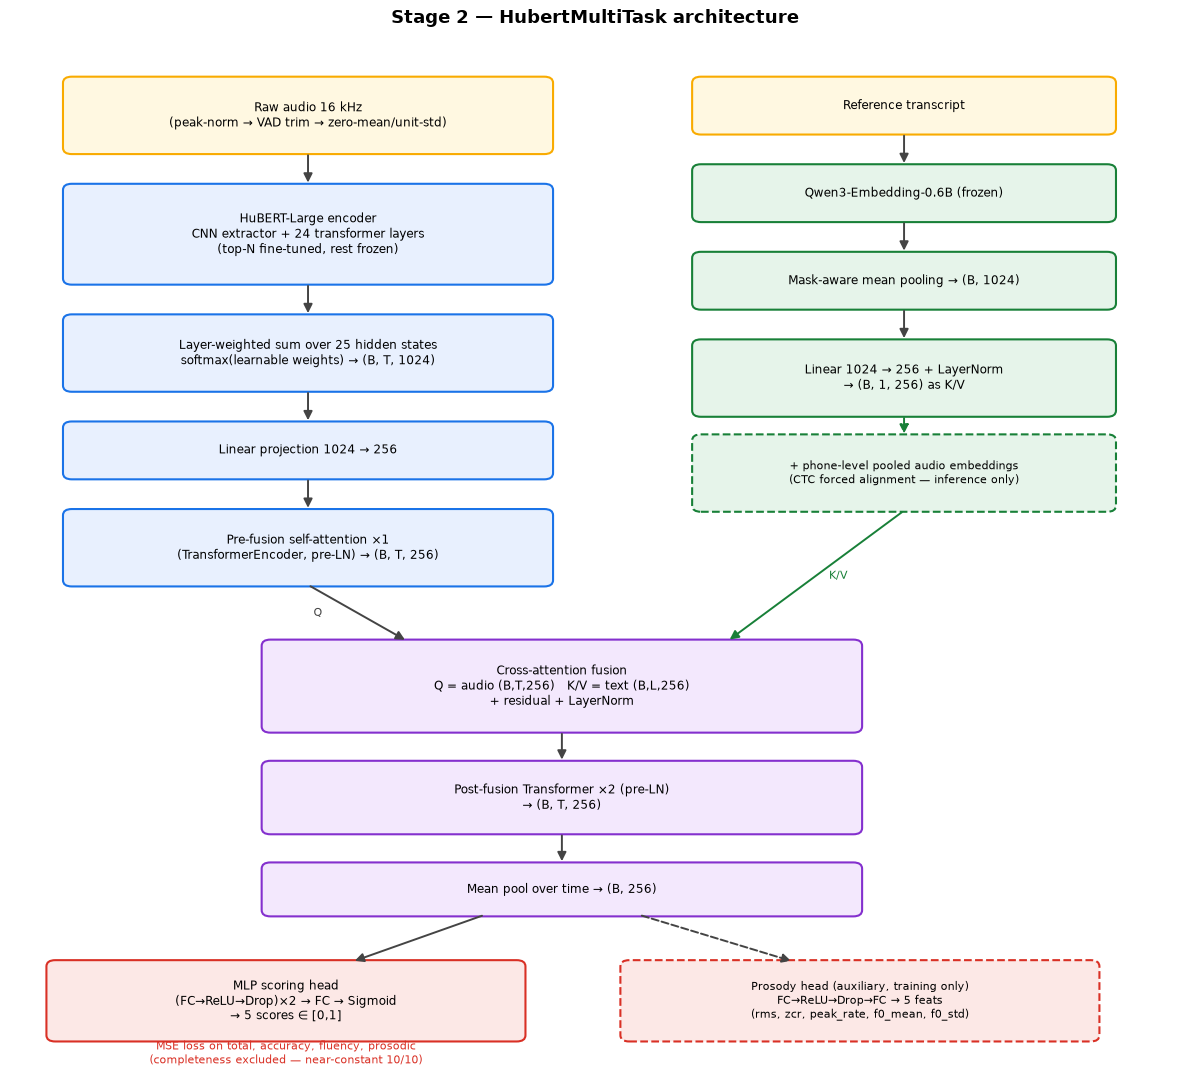

In [5]:
fig, ax = canvas(12, 11, "Stage 2 — HubertMultiTask architecture", xmax=10.6, ymax=13.4)

# ---- audio path (left column) ----
audio = vflow(ax, 2.7, 12.8, [
    ("Raw audio 16 kHz\n(peak-norm → VAD trim → zero-mean/unit-std)", "data", 0.95),
    ("HuBERT-Large encoder\nCNN extractor + 24 transformer layers\n(top-N fine-tuned, rest frozen)", "audio", 1.25),
    ("Layer-weighted sum over 25 hidden states\nsoftmax(learnable weights) → (B, T, 1024)", "audio", 0.95),
    ("Linear projection 1024 → 256", "audio", 0.7),
    ("Pre-fusion self-attention ×1\n(TransformerEncoder, pre-LN) → (B, T, 256)", "audio", 0.95),
], w=4.4, gap=0.42, fs=8.5)

# ---- text path (right column) ----
text = vflow(ax, 8.1, 12.8, [
    ("Reference transcript", "data", 0.7),
    ("Qwen3-Embedding-0.6B (frozen)", "text", 0.7),
    ("Mask-aware mean pooling → (B, 1024)", "text", 0.7),
    ("Linear 1024 → 256 + LayerNorm\n→ (B, 1, 256) as K/V", "text", 0.95),
], w=3.8, gap=0.42, fs=8.5)

# dashed optional phone path
box(ax, 8.1, 7.75, 3.8, 0.95, "+ phone-level pooled audio embeddings\n(CTC forced alignment — inference only)", "text", 8, ls="--")
arrow(ax, (8.1, text[-1][2]), (8.1, 8.22), ls="--", color="#188038")

# ---- fusion column (center) ----
fusion = vflow(ax, 5.0, 5.6, [
    ("Cross-attention fusion\nQ = audio (B,T,256)   K/V = text (B,L,256)\n+ residual + LayerNorm", "fusion", 1.15),
    ("Post-fusion Transformer ×2 (pre-LN)\n→ (B, T, 256)", "fusion", 0.9),
    ("Mean pool over time → (B, 256)", "fusion", 0.65),
], w=5.4, gap=0.4, fs=8.5)

arrow(ax, (2.7, audio[-1][2]), (3.6, 5.6), "Q", dx=-0.4)
arrow(ax, (8.1, 7.27), (6.5, 5.6), "K/V", color="#188038")

# ---- heads ----
box(ax, 2.5, 1.0, 4.3, 1.0, "MLP scoring head\n(FC→ReLU→Drop)×2 → FC → Sigmoid\n→ 5 scores ∈ [0,1]", "head", 8.5)
box(ax, 7.7, 1.0, 4.3, 1.0, "Prosody head (auxiliary, training only)\nFC→ReLU→Drop→FC → 5 feats\n(rms, zcr, peak_rate, f0_mean, f0_std)", "head", 8, ls="--")
arrow(ax, (4.3, fusion[-1][2]), (3.1, 1.5))
arrow(ax, (5.7, fusion[-1][2]), (7.1, 1.5), ls="--")

ax.text(2.5, 0.2, "MSE loss on total, accuracy, fluency, prosodic\n(completeness excluded — near-constant 10/10)",
        fontsize=8, ha="center", color="#d93025")
plt.tight_layout(); plt.show()

### Live introspection — parameters and freeze map

Load the real model (stage-1 backbone if available, text stream off to keep this light)
and check that the diagram matches reality.

/workspace/pronunciation-scoring/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Backbone: outputs/hubert-large-speechocean-ctc


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 7380.46it/s]

[transformers] HubertModel LOAD REPORT from: outputs/hubert-large-speechocean-ctc
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,component,total (M),trainable (M),frozen (M)
0,HuBERT CNN feature extractor,4.210,4.210,0.000
1,HuBERT feature projection,0.526,0.526,0.000
2,HuBERT transformer encoder,310.701,151.155,159.546
3,audio_proj (1024→256),0.262,0.262,0.000
4,pre-fusion audio transformer,0.790,0.790,0.000
5,cross_attn_fusion,0.264,0.264,0.000
6,post-fusion transformer,1.580,1.580,0.000
7,MLP scoring head,0.133,0.133,0.000
8,prosody head (aux),0.067,0.067,0.000
9,layer_weights,0.000,0.000,0.000


TOTAL: 318.5M parameters — 159.0M trainable, 159.5M frozen (num_unfreeze_hubert_layers=12 → top half of the 24 HuBERT layers)


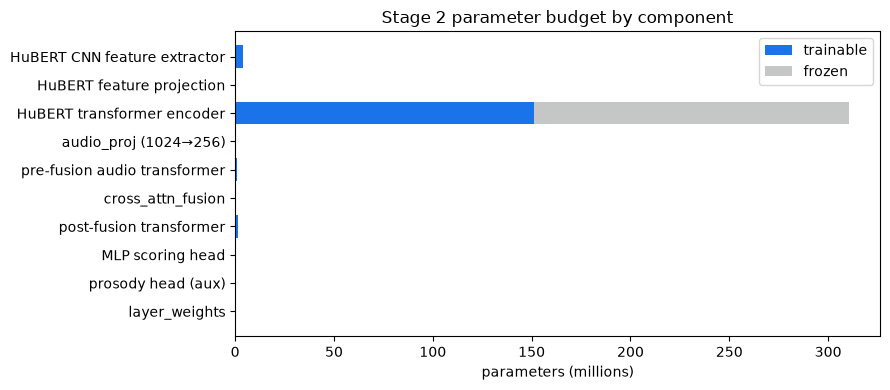

In [6]:
import torch
from stage2_scoring.hubert_multitask import HubertMultiTask

STAGE1_DIR = "outputs/hubert-large-speechocean-ctc"
backbone = STAGE1_DIR if os.path.isdir(STAGE1_DIR) else "facebook/hubert-large-ll60k"
print("Backbone:", backbone)

model = HubertMultiTask(model_name=backbone, text_model_name=None).eval()

def count(m):
    total = sum(p.numel() for p in m.parameters())
    train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, train

components = {
    "HuBERT CNN feature extractor": model.hubert.feature_extractor,
    "HuBERT feature projection":    model.hubert.feature_projection,
    "HuBERT transformer encoder":   model.hubert.encoder,
    "audio_proj (1024→256)":        model.audio_proj,
    "pre-fusion audio transformer": model.audio_transformer,
    "cross_attn_fusion":            model.cross_attn_fusion,
    "post-fusion transformer":      model.transformer,
    "MLP scoring head":             model.scorer,
    "prosody head (aux)":           model.prosody_feat_head,
}
rows = []
for name, mod in components.items():
    total, train = count(mod)
    rows.append((name, total/1e6, train/1e6, (total-train)/1e6))
rows.append(("layer_weights", model.layer_weights.numel()/1e6, model.layer_weights.numel()/1e6, 0.0))

df = pd.DataFrame(rows, columns=["component", "total (M)", "trainable (M)", "frozen (M)"]).round(3)
display(df)
t, tr = count(model)
print(f"TOTAL: {t/1e6:.1f}M parameters — {tr/1e6:.1f}M trainable, {(t-tr)/1e6:.1f}M frozen "
      f"(num_unfreeze_hubert_layers=12 → top half of the 24 HuBERT layers)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df["component"], df["trainable (M)"], color="#1a73e8", label="trainable")
ax.barh(df["component"], df["frozen (M)"], left=df["trainable (M)"], color="#c4c7c5", label="frozen")
ax.set_xlabel("parameters (millions)"); ax.invert_yaxis(); ax.legend()
ax.set_title("Stage 2 parameter budget by component")
plt.tight_layout(); plt.show()

### Live introspection — tensor shapes through the pipeline

Trace a 2-second dummy waveform step by step (a random `(1, 1, 256)` tensor stands in for the
projected text embedding so the fusion path is exercised without downloading Qwen3-Embedding).

In [7]:
with torch.inference_mode():
    wav = torch.randn(1, 32000)                                   # 2 s @ 16 kHz
    steps = [("raw waveform", wav)]

    hidden = model._layer_weighted_encode(wav)                    # layer-weighted HuBERT
    steps.append(("HuBERT layer-weighted sum", hidden))

    audio = model.audio_proj(hidden)
    steps.append(("audio projection", audio))

    audio = model.audio_transformer(audio)
    steps.append(("pre-fusion self-attention", audio))

    text_kv = torch.randn(1, 1, audio.size(-1))                   # stand-in text embedding
    steps.append(("text K/V (projected)", text_kv))

    fused = model.cross_attn_fusion(audio, text_kv)
    steps.append(("cross-attention fusion", fused))

    refined = model.transformer(fused)
    steps.append(("post-fusion transformer", refined))

    utt = refined.mean(dim=1)
    steps.append(("mean pool over time", utt))

    steps.append(("sentence scores (sigmoid)", model.scorer(utt)))
    steps.append(("prosody prediction (aux)", model.prosody_feat_head(utt)))

for name, t in steps:
    print(f"{name:32s} {tuple(t.shape)}")
print("\n2 s × ~50 frames/s ≈ 99 frames (CNN edge effects) — matches HUBERT_FRAME_HZ in stage2_scoring/constants.py")

raw waveform                     (1, 32000)
HuBERT layer-weighted sum        (1, 99, 1024)
audio projection                 (1, 99, 256)
pre-fusion self-attention        (1, 99, 256)
text K/V (projected)             (1, 1, 256)
cross-attention fusion           (1, 99, 256)
post-fusion transformer          (1, 99, 256)
mean pool over time              (1, 256)
sentence scores (sigmoid)        (1, 5)
prosody prediction (aux)         (1, 5)

2 s × ~50 frames/s ≈ 99 frames (CNN edge effects) — matches HUBERT_FRAME_HZ in stage2_scoring/constants.py


### Learnable layer weights

The audio embedding is a softmax-weighted sum over all 25 HuBERT hidden states. Before
training the weights are uniform (1/25 each); if a trained `best.pt` exists in
`outputs/ckpt_hubert_multitask/`, its learned weights are shown instead.

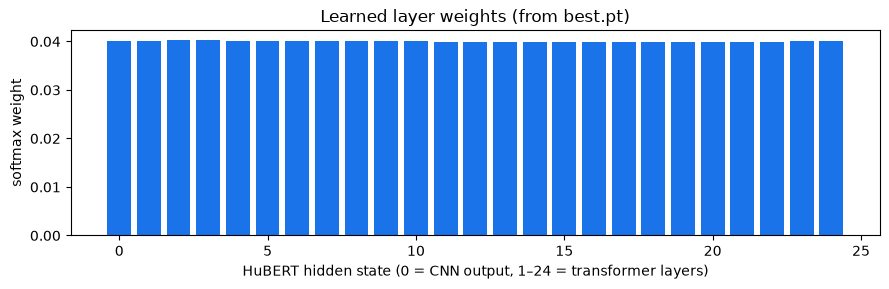

In [8]:
ckpt = "outputs/ckpt_hubert_multitask/best.pt"
if os.path.exists(ckpt):
    state = torch.load(ckpt, map_location="cpu", weights_only=True)
    lw = state["layer_weights"]
    title = "Learned layer weights (from best.pt)"
else:
    lw = model.layer_weights.detach()
    title = "Layer weights (untrained — uniform until stage 2 is trained)"

w = torch.softmax(lw, dim=0).numpy()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(w)), w, color="#1a73e8")
ax.set_xlabel("HuBERT hidden state (0 = CNN output, 1–24 = transformer layers)")
ax.set_ylabel("softmax weight"); ax.set_title(title)
plt.tight_layout(); plt.show()

---
## How to run each stage

```bash
# Stage 1 — CTC fine-tuning (writes outputs/hubert-large-speechocean-ctc/)
python -m stage1_ctc.train

# Stage 2 — scoring model, starting from the stage-1 encoder
python -m stage2_scoring.train --backbone stage1

# Stage 2 from the stock pretrained HuBERT-Large
python -m stage2_scoring.train --backbone hubert-large
```

See `AGENTS.md` for the full reproducibility guide.